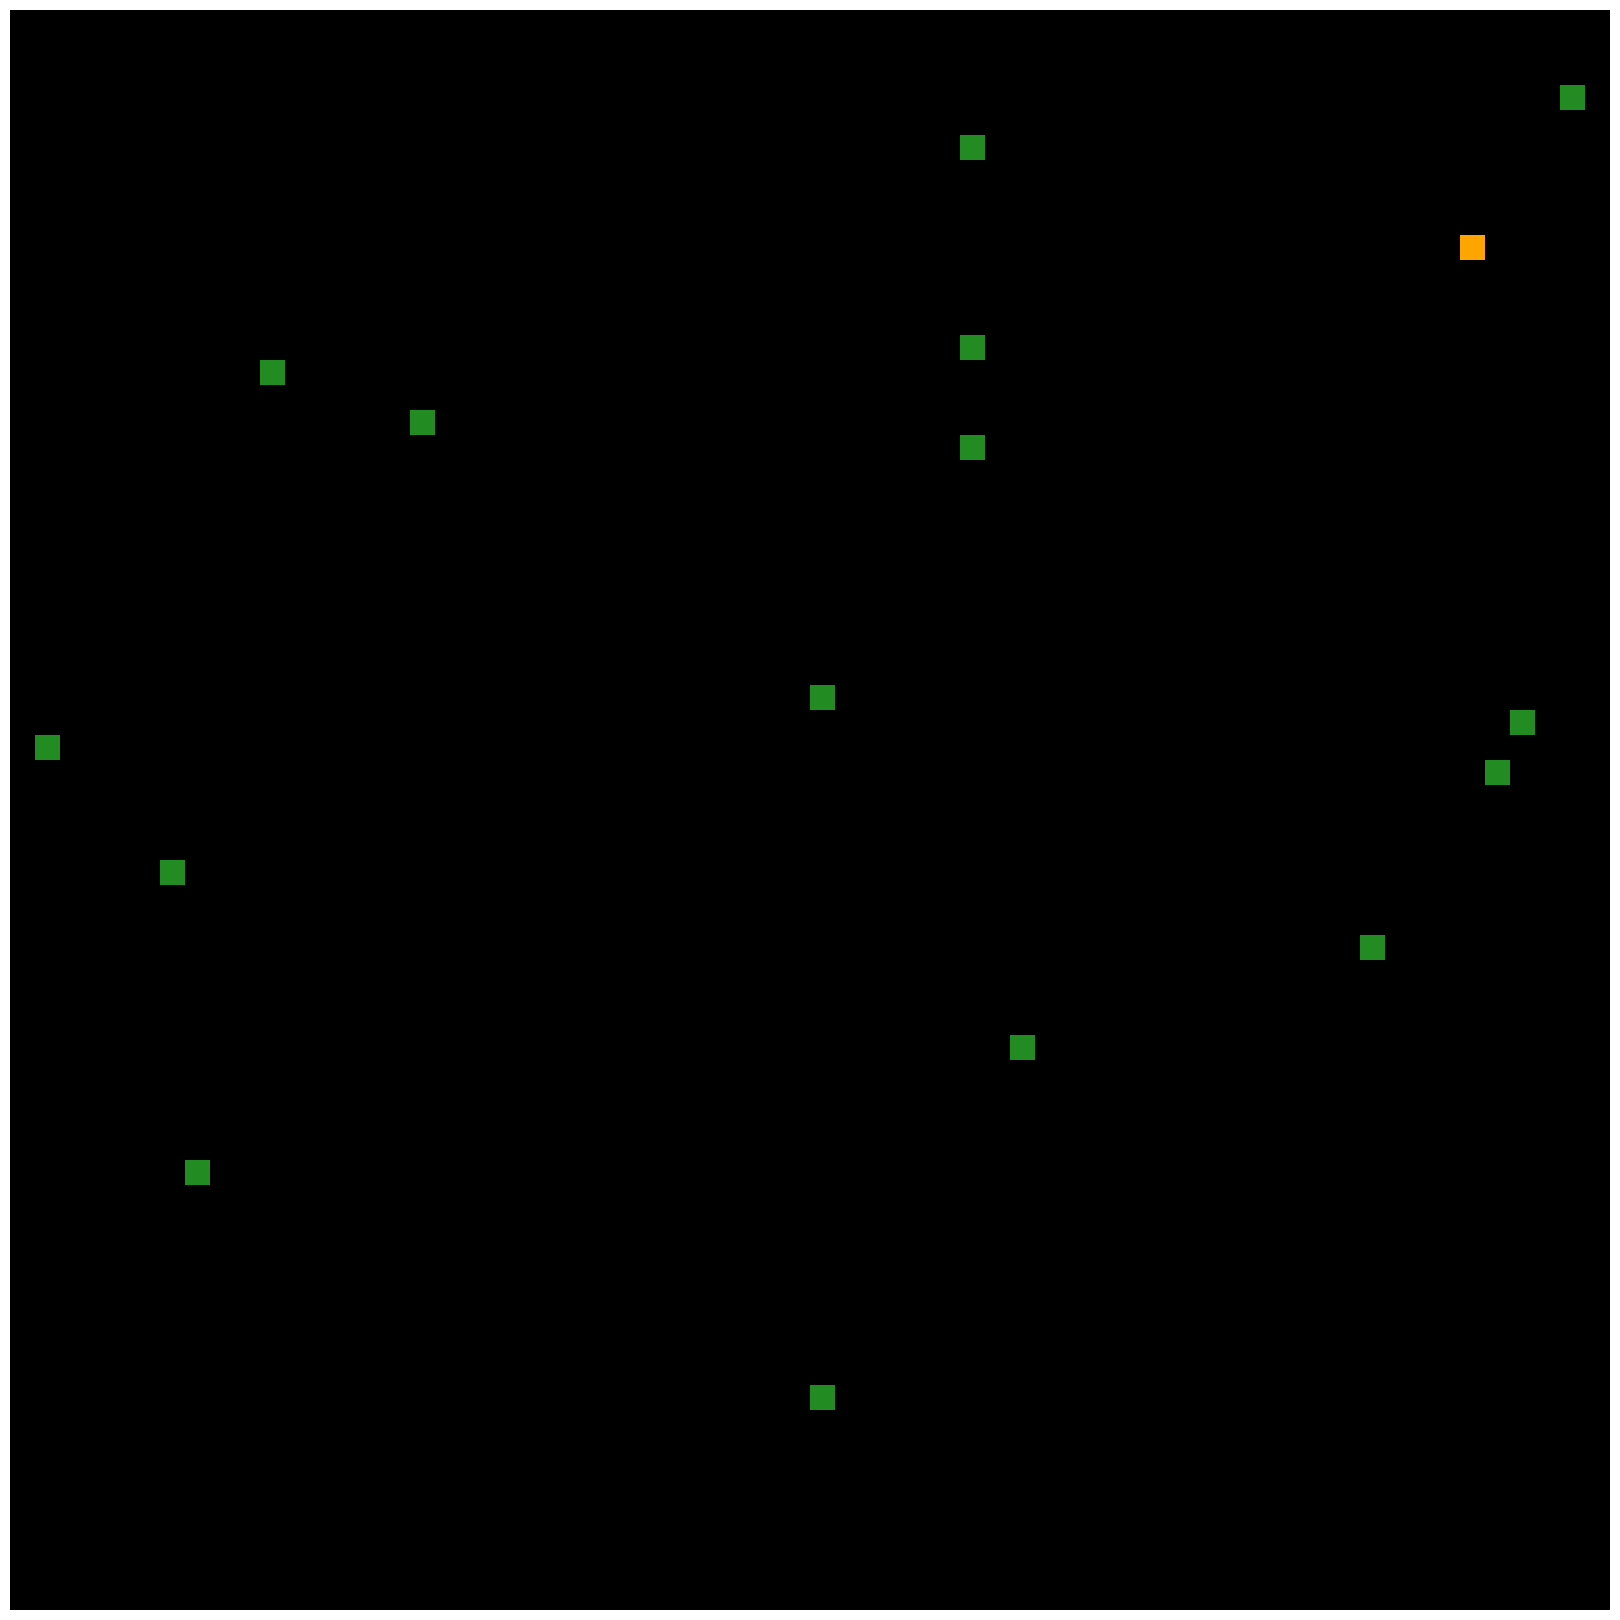

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors
from matplotlib.colors import BoundaryNorm

class WFSim:
    def __init__(self, f=0.01, p=1e-4, h=16, w=16):
        self.f = f  # fire probability
        self.p = p  # tree growing probability
        self.h = h  # grid height
        self.w = w  # grid width

        # Generating initial grid (1: tree, 0: empty)
        self.landscape = np.random.randint(1, 2, (self.h, self.w))

    def fire_neighbors_check(self, idx, jdx):
        """Check if any neighboring cells are on fire."""
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:  # Check bounds
                if self.landscape[ni, nj] == 2:  # Neighbor is on fire
                    return True
        return False

    def step(self, step):
        """Update the grid based on rules."""
        new_landscape = self.landscape.copy()

        for i in range(self.h):
            for j in range(self.w):
                if self.landscape[i, j] == 2:  # Burning tree
                    new_landscape[i, j] = 0  # Turn into ash
                elif self.landscape[i, j] == 0 and self.p > np.random.rand():
                    new_landscape[i, j] = 1  # Tree grows
                elif (
                    self.landscape[i, j] == 1
                    and (self.f > np.random.rand() or self.fire_neighbors_check(i, j))
                ):
                    new_landscape[i, j] = 2  # Tree catches fire

        self.landscape = new_landscape

# Fungsi untuk memperbarui setiap frame dalam animasi
def update(frame):
    Sim.step(frame)
    im.set_data(Sim.landscape)
    ax.axis("off")  # Hilangkan axis
    return [im]

# Warna untuk simulasi
colors_list = ["black", "forestgreen", "orange"]  # 0: empty, 1: tree, 2: fire
cmap = colors.ListedColormap(colors_list)
bounds = [0, 1, 2, 3]  # Nilai 0, 1, dan 2
norm = BoundaryNorm(bounds, cmap.N)

# Inisialisasi simulasi
Sim = WFSim(h=64, w=64)

# Membuat plot
fig, ax = plt.subplots(figsize=(16, 16))
im = ax.imshow(Sim.landscape, cmap=cmap, norm=norm)

# Hilangkan padding di sekitar plot
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

# Membuat animasi
ani = animation.FuncAnimation(fig, update, frames=80, interval=20)

# Menyimpan animasi
ani.save("simple.gif", fps=1.5, savefig_kwargs={"pad_inches": 0})

# Menampilkan plot
plt.show()

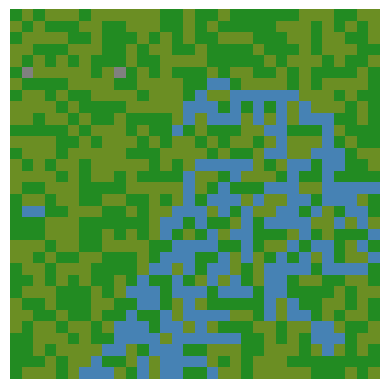

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

class WFSim:
    def __init__(self, f=0.01, p=1e-4, bedrock=0.005, water=0.05, h=16, w=16):
        self.f = f  # Fire probability
        self.p = p  # Tree growing probability
        self.h = h  # Grid height
        self.w = w  # Grid width
        self.bedrock = bedrock  # Bedrock probability
        self.water = water  # Water probability

        # Initialize the landscape
        self.landscape = np.random.randint(0, 2, (self.h, self.w))  # 0: grass, 1: tree

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                coef = 5 if self.surf_neighbors_check(i, j, "B") else 1
                if self.bedrock * coef > np.random.random():
                    self.landscape[i, j] = -2  # Bedrock

                coef = 10 if self.surf_neighbors_check(i, j, "W") else 0.1
                if self.water * coef > np.random.random():
                    self.landscape[i, j] = -3  # Water

    def surf_neighbors_check(self, idx, jdx, terrain_type):
        """Check for specific terrain type in neighbors."""
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
        terrain_value = -2 if terrain_type == "B" else -3 if terrain_type == "W" else None
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == terrain_value:
                    return True
        return False

    def fire_neighbors_check(self, idx, jdx):
        """Check if any neighboring cells are on fire."""
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == 2:  # Fire
                    return True
        return False

    def step(self, step):
        """Simulate one step in the landscape."""
        new_landscape = self.landscape.copy()

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                if self.landscape[i, j] == 2:  # Burning tree
                    new_landscape[i, j] = 0  # Turn into ash

                if self.landscape[i, j] == 0 and self.p > np.random.rand():
                    new_landscape[i, j] = 1  # Growing a tree

                if (
                    self.landscape[i, j] == 1
                    and (self.f > np.random.rand() or self.fire_neighbors_check(i, j))
                ):
                    new_landscape[i, j] = 2  # Tree catches fire

        self.landscape = new_landscape

# Warna untuk simulasi
colors_list = ["steelblue", "grey", "black", "olivedrab", "forestgreen", "orange"]
cmap = colors.ListedColormap(colors_list)
bounds = [-3, -2, -1, 0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

# Inisialisasi simulasi
Sim = WFSim(h=32, w=32)

# Plot landscape
plt.imshow(Sim.landscape, cmap=cmap, norm=norm)
plt.axis(False)
plt.savefig("Landscape.png", pad_inches=0, bbox_inches="tight")
plt.show()


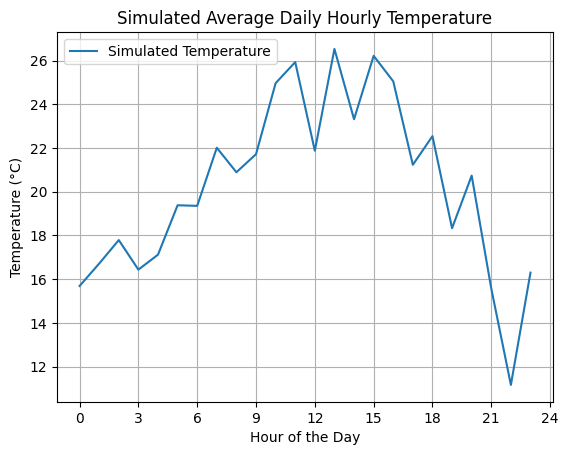

In [ ]:
average_temp = 20
amplitude = 5
noise_level = 2
hours_in_day = 24

hours = np.arange(hours_in_day)
temperatures = average_temp + amplitude * np.sin(2 * np.pi * hours / 24 - np.pi / 2)

temperatures += np.random.normal(0, noise_level, 24) #noise

plt.plot(hours, temperatures, label='Simulated Temperature')
plt.xlabel('Hour of the Day')
plt.ylabel('Temperature (°C)')
plt.title('Simulated Average Daily Hourly Temperature')
plt.xticks(np.arange(0, 25, 3))
plt.legend()
plt.grid(True)
plt.savefig('temperature.png')
plt.show()

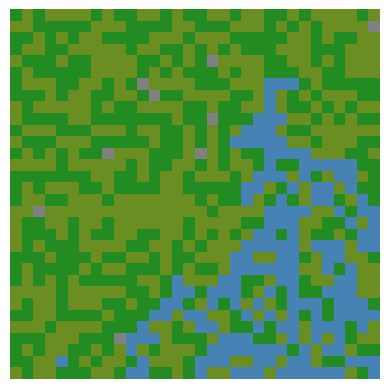

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

class WFSim:
    def __init__(self, f=0.01, p=1e-4, bedrock=0.005, water=0.05, h=16, w=16):
        self.f = f  # Fire probability
        self.p = p  # Tree growing probability
        self.h = h  # Grid height
        self.w = w  # Grid width
        self.bedrock = bedrock  # Bedrock probability
        self.water = water  # Water probability

        # Initialize the landscape
        self.landscape = np.random.randint(0, 2, (self.h, self.w))  # 0: grass, 1: tree

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                coef = 5 if self.surf_neighbors_check(i, j, "B") else 1
                if self.bedrock * coef > np.random.random():
                    self.landscape[i, j] = -2  # Bedrock

                coef = 10 if self.surf_neighbors_check(i, j, "W") else 0.1
                if self.water * coef > np.random.random():
                    self.landscape[i, j] = -3  # Water

    def surf_neighbors_check(self, idx, jdx, terrain_type):
        """Check for specific terrain type in neighbors."""
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
        terrain_value = -2 if terrain_type == "B" else -3 if terrain_type == "W" else None
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == terrain_value:
                    return True
        return False

    def fire_neighbors_check(self, idx, jdx):
        """Check if any neighboring cells are on fire."""
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == 2:  # Fire
                    return True
        return False

    def step(self, step):
        """Simulate one step in the landscape."""
        new_landscape = self.landscape.copy()

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                if self.landscape[i, j] == 2:  # Burning tree
                    new_landscape[i, j] = 0  # Turn into ash

                if self.landscape[i, j] == 0 and self.p > np.random.rand():
                    new_landscape[i, j] = 1  # Growing a tree

                if (
                    self.landscape[i, j] == 1
                    and (self.f > np.random.rand() or self.fire_neighbors_check(i, j))
                ):
                    new_landscape[i, j] = 2  # Tree catches fire

        self.landscape = new_landscape

# Warna untuk simulasi
colors_list = ["steelblue", "grey", "black", "olivedrab", "forestgreen", "orange"]
cmap = colors.ListedColormap(colors_list)
bounds = [-3, -2, -1, 0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

# Inisialisasi simulasi
Sim = WFSim(h=32, w=32)

# Plot landscape
plt.imshow(Sim.landscape, cmap=cmap, norm=norm)
plt.axis(False)
plt.savefig("Landscape.png", pad_inches=0, bbox_inches="tight")
plt.show()

def step(self, step):
    """Simulate one step in the landscape."""
    # Salin landscape saat ini untuk pembaruan
    new_landscape = self.landscape.copy()

    for i in range(self.landscape.shape[0]):
        for j in range(self.landscape.shape[1]):

            if self.landscape[i, j] == 2:  # Jika sel adalah pohon yang terbakar
                new_landscape[i, j] = -1  # Ubah menjadi abu (-1)

            if self.landscape[i, j] == 0 and self.p > np.random.rand():
                new_landscape[i, j] = 1  # Pohon baru tumbuh (1)

            if (
                self.landscape[i, j] == 1
                and (self.f > np.random.rand() or self.fire_neighbors_check(i, j))
            ):
                new_landscape[i, j] = 2  # Pohon terbakar (2)

    # Perbarui landscape dengan nilai baru
    self.landscape = new_landscape
def step(self, step):
    """Simulate one step in the landscape."""
    # Salin landscape saat ini untuk pembaruan
    new_landscape = self.landscape.copy()

    for i in range(self.landscape.shape[0]):
        for j in range(self.landscape.shape[1]):

            if self.landscape[i, j] == 2:  # Jika sel adalah pohon yang terbakar
                new_landscape[i, j] = -1  # Ubah menjadi abu (-1)

            if self.landscape[i, j] == 0 and self.p > np.random.rand():
                new_landscape[i, j] = 1  # Pohon baru tumbuh (1)

            if (
                self.landscape[i, j] == 1
                and (self.f > np.random.rand() or self.fire_neighbors_check(i, j))
            ):
                new_landscape[i, j] = 2  # Pohon terbakar (2)

    # Perbarui landscape dengan nilai baru
    self.landscape = new_landscape


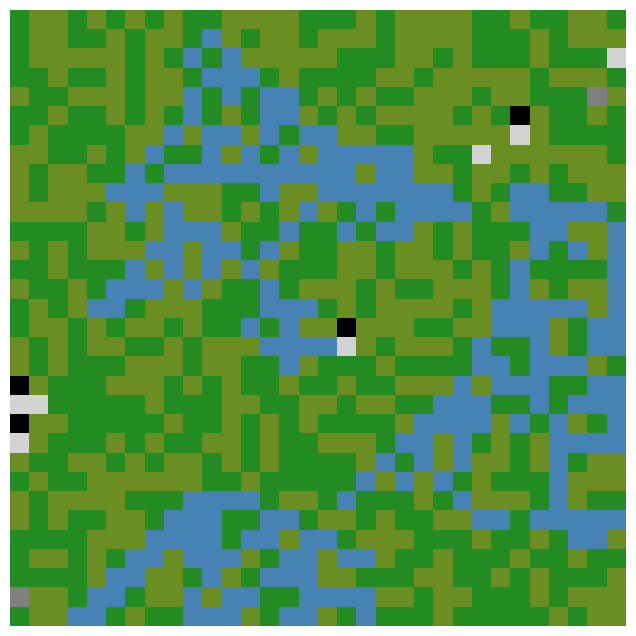

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors

class WFSim:
    def __init__(self, f=0.01, p=1e-4, bedrock=0.005, water=0.05, h=32, w=32):
        self.f = f  # Fire probability
        self.p = p  # Tree growing probability
        self.h = h  # Grid height
        self.w = w  # Grid width
        self.bedrock = bedrock  # Bedrock probability
        self.water = water  # Water probability

        # Landscape initialization
        self.landscape = np.random.randint(0, 2, (self.h, self.w))  # 0: grass, 1: tree

        # Wind properties
        self.wind = np.random.choice(['calm', 'S', 'N', 'W', 'E', 'SW', 'SE', 'NW', 'NE'])
        self.offsets = {
            'calm': [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)],
            'N': [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1)],
            'S': [(0, -1), (0, 1), (1, -1), (1, 0), (1, 1)],
            'E': [(-1, 0), (-1, 1), (0, 1), (1, 0), (1, 1)],
            'W': [(-1, -1), (-1, 0), (0, -1), (1, -1), (1, 0)],
            'NE': [(-1, 0), (-1, 1), (0, 1)],
            'NW': [(-1, -1), (-1, 0), (0, -1)],
            'SE': [(0, 1), (1, 0), (1, 1)],
            'SW': [(0, -1), (1, -1), (1, 0)]
        }

        # Initialize terrain (bedrock and water)
        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                coef = 5 if self.surf_neighbors_check(i, j, "B") else 1
                if self.bedrock * coef > np.random.random():
                    self.landscape[i, j] = -2  # Bedrock

                coef = 10 if self.surf_neighbors_check(i, j, "W") else 0.1
                if self.water * coef > np.random.random():
                    self.landscape[i, j] = -3  # Water

    def surf_neighbors_check(self, idx, jdx, terrain_type):
        """Check for specific terrain type in neighbors."""
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
        terrain_value = -2 if terrain_type == "B" else -3 if terrain_type == "W" else None
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == terrain_value:
                    return True
        return False

    def fire_neighbors_check(self, idx, jdx):
        """Check if any neighboring cells are on fire considering wind."""
        offsets = self.offsets[self.wind]
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == 2:  # Fire
                    return True
        return False

    def step(self, step):
        """Simulate one step in the landscape."""
        # Copy current landscape for updates
        new_landscape = self.landscape.copy()

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):

                if self.landscape[i, j] == 2:  # Tree burning
                    new_landscape[i, j] = -1  # Turn to ash

                if self.landscape[i, j] == 0 and self.p > np.random.rand():
                    new_landscape[i, j] = 1  # Tree grows

                if (
                    self.landscape[i, j] == 1
                    and (self.f > np.random.rand() or self.fire_neighbors_check(i, j))
                ):
                    new_landscape[i, j] = 2  # Tree catches fire

        # Update landscape with simulation result
        self.landscape = new_landscape

# Define colors for the simulation
colors_list = ["steelblue", "grey", "black", "olivedrab", "forestgreen", "orange", "lightgrey"]
cmap = colors.ListedColormap(colors_list)
bounds = [-3, -2, -1, 0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

# Initialize simulation
Sim = WFSim(h=32, w=32)

# Create animation
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(Sim.landscape, cmap=cmap, norm=norm)
ax.axis('off')

def update(frame):
    Sim.step(frame)
    im.set_data(Sim.landscape)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=100, interval=200, blit=True)
plt.show()

# Save the animation
ani.save("forest_fire_simulation.gif", fps=5, writer="imagemagick")


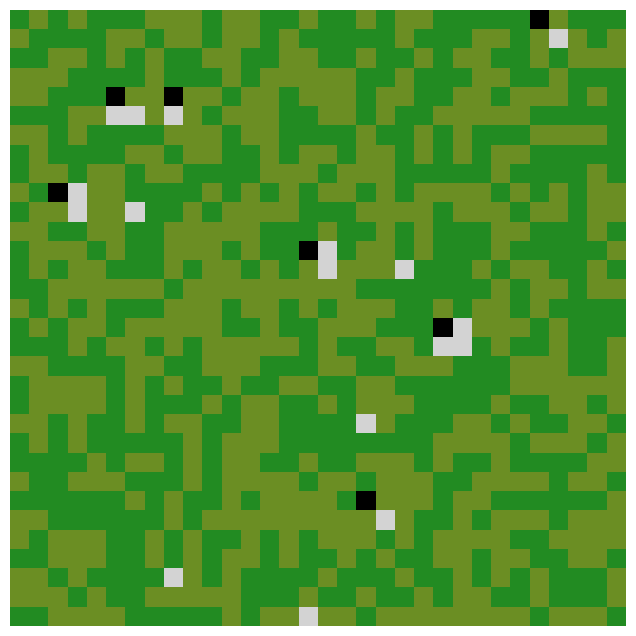

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors


class WFSim:
    def __init__(self, f=0.01, p=1e-4, cloud=0.1, bedrock=0.005, water=0.05, h=32, w=32):
        self.f = f  # Fire probability
        self.p = p  # Tree growing probability
        self.cloud = cloud  # Cloud generation probability
        self.h = h  # Grid height
        self.w = w  # Grid width
        self.bedrock = bedrock  # Bedrock probability
        self.water = water  # Water probability

        # Initialize landscape
        self.landscape = np.random.randint(0, 2, (self.h, self.w))  # 0: grass, 1: tree
        self.old_landscape = self.landscape.copy()
        self.wind = np.random.choice(['calm', 'S', 'N', 'W', 'E', 'SW', 'SE', 'NW', 'NE'])
        self.temp = [15 + 10 * np.sin(np.pi * t / 12) for t in range(24)]  # Daily temperature cycle

        self.offsets = {
            'calm': [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)],
            'N': [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1)],
            'S': [(0, -1), (0, 1), (1, -1), (1, 0), (1, 1)],
            'E': [(-1, 0), (-1, 1), (0, 1), (1, 0), (1, 1)],
            'W': [(-1, -1), (-1, 0), (0, -1), (1, -1), (1, 0)],
            'NE': [(-1, 0), (-1, 1), (0, 1)],
            'NW': [(-1, -1), (-1, 0), (0, -1)],
            'SE': [(0, 1), (1, 0), (1, 1)],
            'SW': [(0, -1), (1, -1), (1, 0)]
        }
        self.cloud_offsets = {
            'calm': [],
            'N': [(1, 0)],
            'S': [(-1, 0)],
            'E': [(0, -1)],
            'W': [(0, 1)],
            'NE': [(1, -1)],
            'NW': [(1, 1)],
            'SE': [(-1, -1)],
            'SW': [(-1, 1)]
        }

    def fire_neighbors_check(self, idx, jdx):
        """Check if any neighboring cells are on fire considering wind."""
        offsets = self.offsets[self.wind]
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == 2:  # Fire
                    return True
        return False

    def generate_cloud(self):
        """Generate a cloud on the grid."""
        size = 16  # Arbitrary cloud size
        mask = np.zeros((self.h, self.w), dtype=bool)
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

        idx_prev, jdx_prev = np.random.randint(0, self.h), np.random.randint(0, self.w)
        for _ in range(size):
            di, dj = offsets[np.random.randint(len(offsets))]
            ni, nj = idx_prev + di, jdx_prev + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                mask[ni, nj] = True
            idx_prev, jdx_prev = ni, nj
        return mask

    def cloud_move(self):
        """Move existing clouds according to wind direction."""
        mask = np.zeros((self.h, self.w), dtype=bool)
        offsets = self.cloud_offsets[self.wind]
        for idx in range(self.landscape.shape[0]):
            for jdx in range(self.landscape.shape[1]):
                for di, dj in offsets:
                    ni, nj = idx + di, jdx + dj
                    if (
                        0 <= ni < self.h
                        and 0 <= nj < self.w
                        and self.landscape[idx, jdx] == 3  # Cloud present
                    ):
                        mask[ni, nj] = True
        return mask

    def step(self, step):
        """Simulate one time step."""
        if step % 24 == 0 and step > 0:
            self.temp = [15 + 10 * np.sin(np.pi * t / 12) for t in range(24)]  # Update temperature

        new_landscape = self.landscape.copy()

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                if new_landscape[i, j] == 3:  # Cloud
                    if self.old_landscape[i, j] in [-1, 2]:  # Ash or fire below
                        new_landscape[i, j] = 0  # Grass regrows
                    else:
                        new_landscape[i, j] = self.old_landscape[i, j]  # Otherwise, maintain
                if new_landscape[i, j] == 2:  # Fire
                    new_landscape[i, j] = -1  # Ash
                if self.p > np.random.rand() and self.landscape[i, j] == 0:  # Grass grows
                    new_landscape[i, j] = 1  # Tree grows
                coef = 2 if self.temp[step % 24] > 25 else 1  # Increase fire chance if hot
                if (
                    self.landscape[i, j] == 1
                    and (self.f * coef > np.random.rand() or self.fire_neighbors_check(i, j))
                ):
                    new_landscape[i, j] = 2  # Tree burns

        self.old_landscape = new_landscape.copy()

        if 3 in self.landscape and self.wind != 'calm':  # Cloud movement
            new_landscape[self.cloud_move()] = 3

        if self.cloud > np.random.rand():  # Generate new cloud
            new_landscape[self.generate_cloud()] = 3

        self.landscape = new_landscape.copy()


# Visualization and animation setup
colors_list = ["steelblue", "grey", "black", "olivedrab", "forestgreen", "orange", "lightgrey"]
cmap = colors.ListedColormap(colors_list)
bounds = [-3, -2, -1, 0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

# Initialize simulation
Sim = WFSim(h=32, w=32)

# Create animation
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(Sim.landscape, cmap=cmap, norm=norm)
ax.axis('off')

def update(frame):
    Sim.step(frame)
    im.set_data(Sim.landscape)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=100, interval=200, blit=True)
plt.show()

# Save the animation
ani.save("final_forest_fire_simulation.gif", fps=2, writer="pillow")


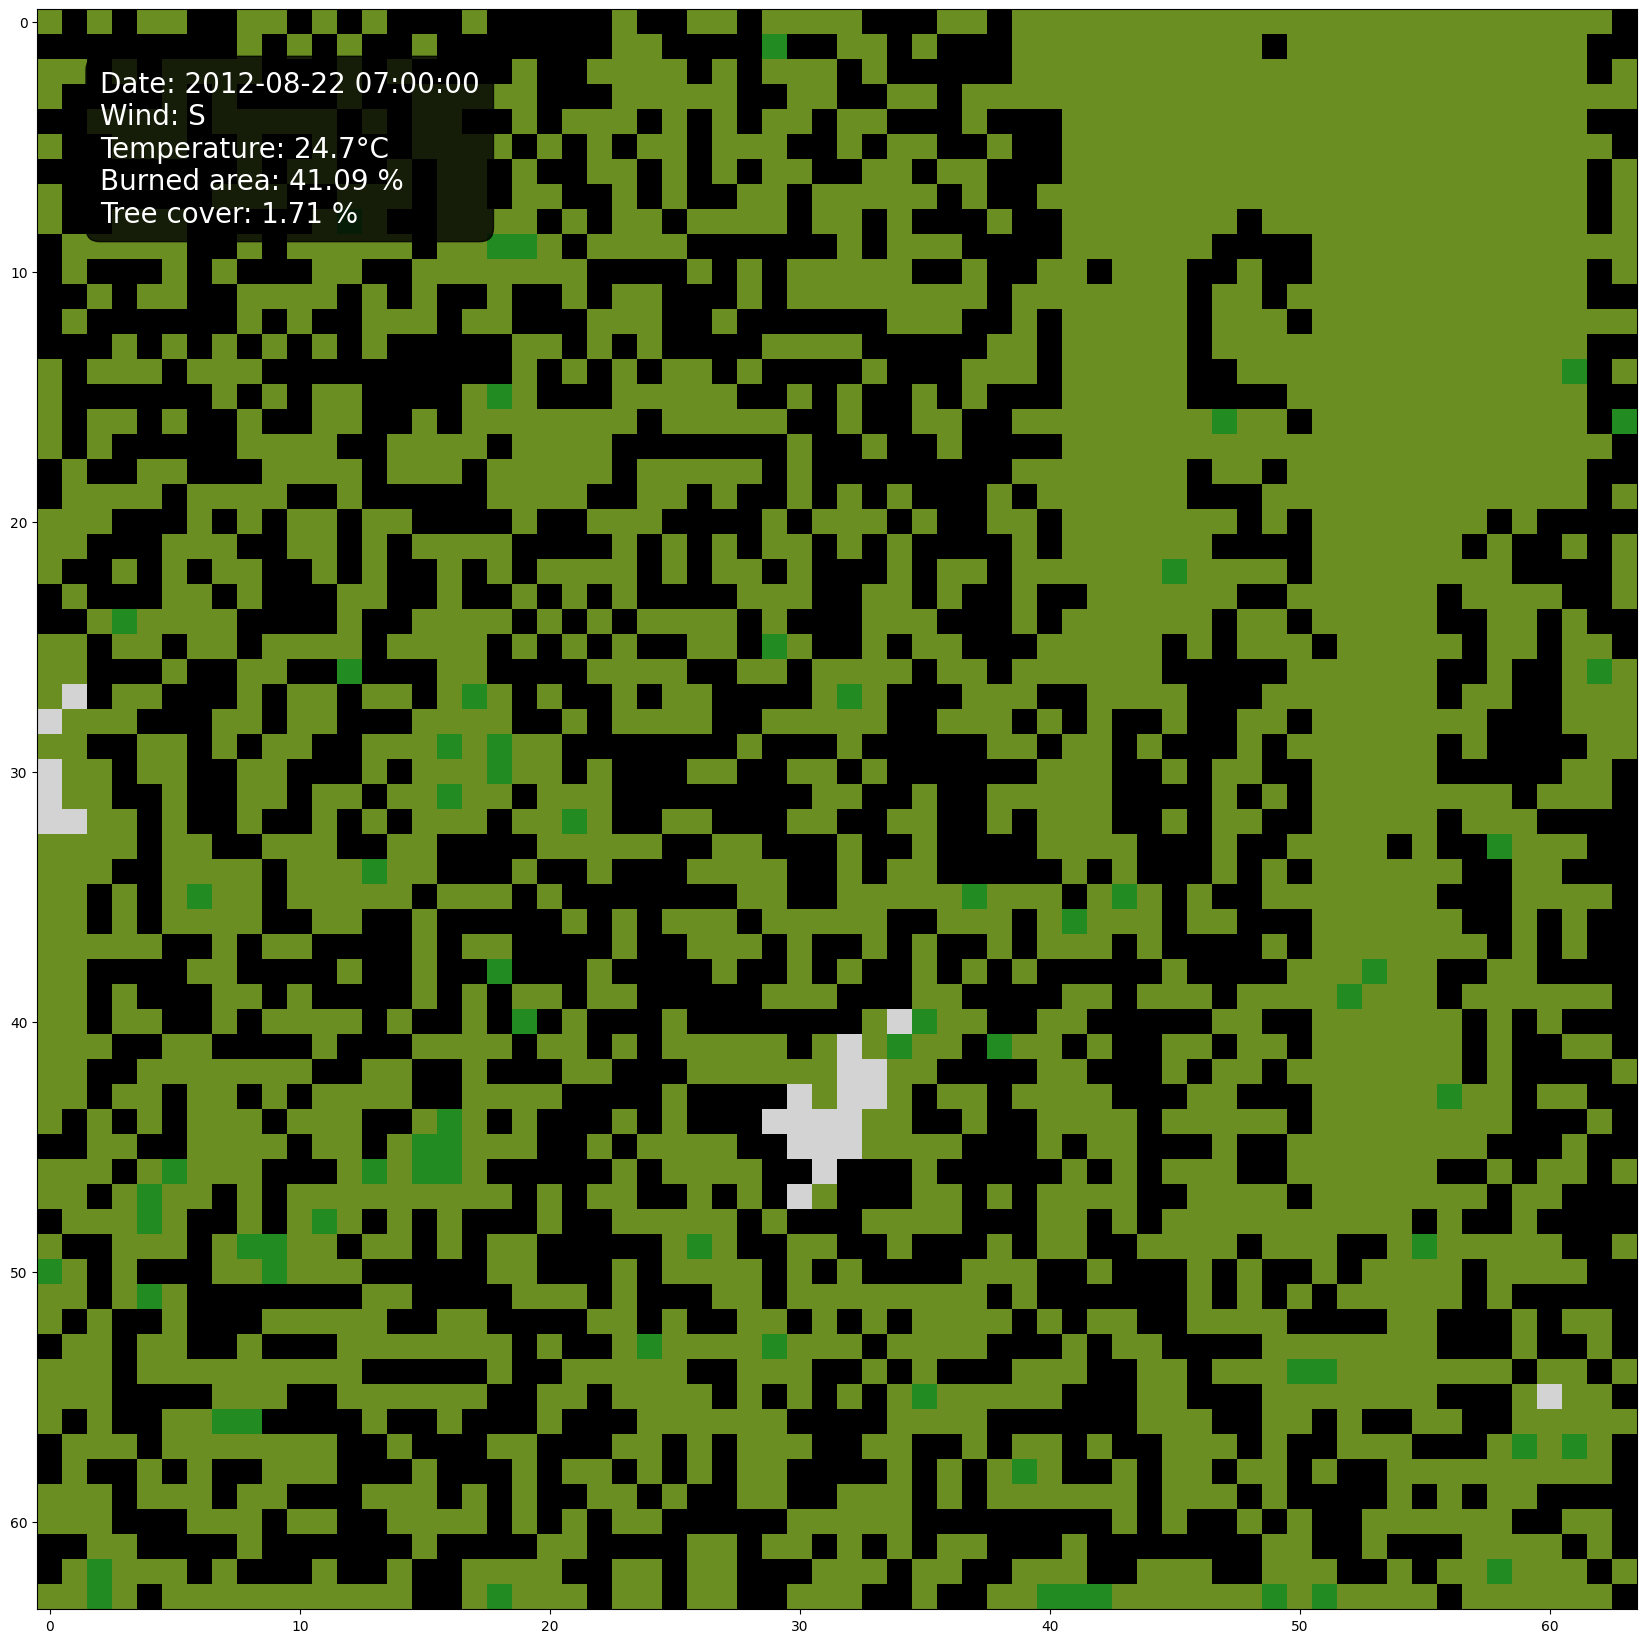

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors
from datetime import datetime, timedelta

class WFSim:
    def __init__(self, f=0.01, p=1e-4, cloud=0.1, bedrock=0.005, water=0.05, h=64, w=64):
        self.f = f  # Fire probability
        self.p = p  # Tree growing probability
        self.cloud = cloud  # Cloud generation probability
        self.h = h  # Grid height
        self.w = w  # Grid width
        self.bedrock = bedrock  # Bedrock probability
        self.water = water  # Water probability

        # Initialize landscape
        self.landscape = np.random.randint(0, 2, (self.h, self.w))  # 0: grass, 1: tree
        self.old_landscape = self.landscape.copy()
        self.wind = np.random.choice(['calm', 'S', 'N', 'W', 'E', 'SW', 'SE', 'NW', 'NE'])
        self.temp = [15 + 10 * np.sin(np.pi * t / 12) for t in range(24)]  # Daily temperature cycle

        self.offsets = {
            'calm': [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)],
            'N': [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1)],
            'S': [(0, -1), (0, 1), (1, -1), (1, 0), (1, 1)],
            'E': [(-1, 0), (-1, 1), (0, 1), (1, 0), (1, 1)],
            'W': [(-1, -1), (-1, 0), (0, -1), (1, -1), (1, 0)],
            'NE': [(-1, 0), (-1, 1), (0, 1)],
            'NW': [(-1, -1), (-1, 0), (0, -1)],
            'SE': [(0, 1), (1, 0), (1, 1)],
            'SW': [(0, -1), (1, -1), (1, 0)]
        }
        self.cloud_offsets = {
            'calm': [],
            'N': [(1, 0)],
            'S': [(-1, 0)],
            'E': [(0, -1)],
            'W': [(0, 1)],
            'NE': [(1, -1)],
            'NW': [(1, 1)],
            'SE': [(-1, -1)],
            'SW': [(-1, 1)]
        }

    def fire_neighbors_check(self, idx, jdx):
        """Check if any neighboring cells are on fire considering wind."""
        offsets = self.offsets[self.wind]
        for di, dj in offsets:
            ni, nj = idx + di, jdx + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                if self.landscape[ni, nj] == 2:  # Fire
                    return True
        return False

    def generate_cloud(self):
        """Generate a cloud on the grid."""
        size = 16  # Arbitrary cloud size
        mask = np.zeros((self.h, self.w), dtype=bool)
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

        idx_prev, jdx_prev = np.random.randint(0, self.h), np.random.randint(0, self.w)
        for _ in range(size):
            di, dj = offsets[np.random.randint(len(offsets))]
            ni, nj = idx_prev + di, jdx_prev + dj
            if 0 <= ni < self.h and 0 <= nj < self.w:
                mask[ni, nj] = True
            idx_prev, jdx_prev = ni, nj
        return mask

    def cloud_move(self):
        """Move existing clouds according to wind direction."""
        mask = np.zeros((self.h, self.w), dtype=bool)
        offsets = self.cloud_offsets[self.wind]
        for idx in range(self.landscape.shape[0]):
            for jdx in range(self.landscape.shape[1]):
                for di, dj in offsets:
                    ni, nj = idx + di, jdx + dj
                    if (
                        0 <= ni < self.h
                        and 0 <= nj < self.w
                        and self.landscape[idx, jdx] == 3  # Cloud present
                    ):
                        mask[ni, nj] = True
        return mask

    def step(self, step):
        """Simulate one time step."""
        if step % 24 == 0 and step > 0:
            self.temp = [15 + 10 * np.sin(np.pi * t / 12) for t in range(24)]  # Update temperature

        new_landscape = self.landscape.copy()

        for i in range(self.landscape.shape[0]):
            for j in range(self.landscape.shape[1]):
                if new_landscape[i, j] == 3:  # Cloud
                    if self.old_landscape[i, j] in [-1, 2]:  # Ash or fire below
                        new_landscape[i, j] = 0  # Grass regrows
                    else:
                        new_landscape[i, j] = self.old_landscape[i, j]  # Otherwise, maintain
                if new_landscape[i, j] == 2:  # Fire
                    new_landscape[i, j] = -1  # Ash
                if self.p > np.random.rand() and self.landscape[i, j] == 0:  # Grass grows
                    new_landscape[i, j] = 1  # Tree grows
                coef = 2 if self.temp[step % 24] > 25 else 1  # Increase fire chance if hot
                if (
                    self.landscape[i, j] == 1
                    and (self.f * coef > np.random.rand() or self.fire_neighbors_check(i, j))
                ):
                    new_landscape[i, j] = 2  # Tree burns

        self.old_landscape = new_landscape.copy()

        if 3 in self.landscape and self.wind != 'calm':  # Cloud movement
            new_landscape[self.cloud_move()] = 3

        if self.cloud > np.random.rand():  # Generate new cloud
            new_landscape[self.generate_cloud()] = 3

        self.landscape = new_landscape.copy()

        # Update statistics
        total_cells = self.h * self.w
        burned_cells = np.sum(self.landscape == -1)
        tree_cells = np.sum(self.landscape == 1)
        self.burned_ratio = round((burned_cells / total_cells) * 100, 2)
        self.tree_cover = round((tree_cells / total_cells) * 100, 2)


# Visualization setup
colors_list = ["steelblue", "grey", "black", "olivedrab", "forestgreen", "orange", "lightgrey"]
cmap = colors.ListedColormap(colors_list)
bounds = [-3, -2, -1, 0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

Sim = WFSim(h=64, w=64)
initial_date = datetime(2012, 8, 19, 0)

fig, ax = plt.subplots(figsize=(16, 16))
im = ax.imshow(Sim.landscape, cmap=cmap, norm=norm)
text = ax.text(2, 8, "", ha="left", fontsize=20, color="white",
               bbox=dict(facecolor="black", alpha=0.8, edgecolor="black", boxstyle="round,pad=0.5"))
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

def update(frame):
    Sim.step(frame)
    im.set_data(Sim.landscape)
    info_text = (
        f"Date: {initial_date + timedelta(hours=frame)}\n"
        f"Wind: {Sim.wind}\n"
        f"Temperature: {round(Sim.temp[frame % 24], 1)}°C\n"
        f"Burned area: {Sim.burned_ratio} %\n"
        f"Tree cover: {Sim.tree_cover} %"
    )
    text.set_text(info_text)
    return [im, text]

ani = animation.FuncAnimation(fig, update, frames=80, interval=200, blit=True)
ani.save("final_forest_fire_simulation.gif", fps=2, writer="pillow")
plt.show()
